In [253]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [254]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [255]:
df = pd.read_csv('/Users/sarfarazali/Downloads/ Projects/KNN-Diabetes-Prediction-System/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [256]:
df.shape

(768, 9)

In [257]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [258]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [259]:
df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

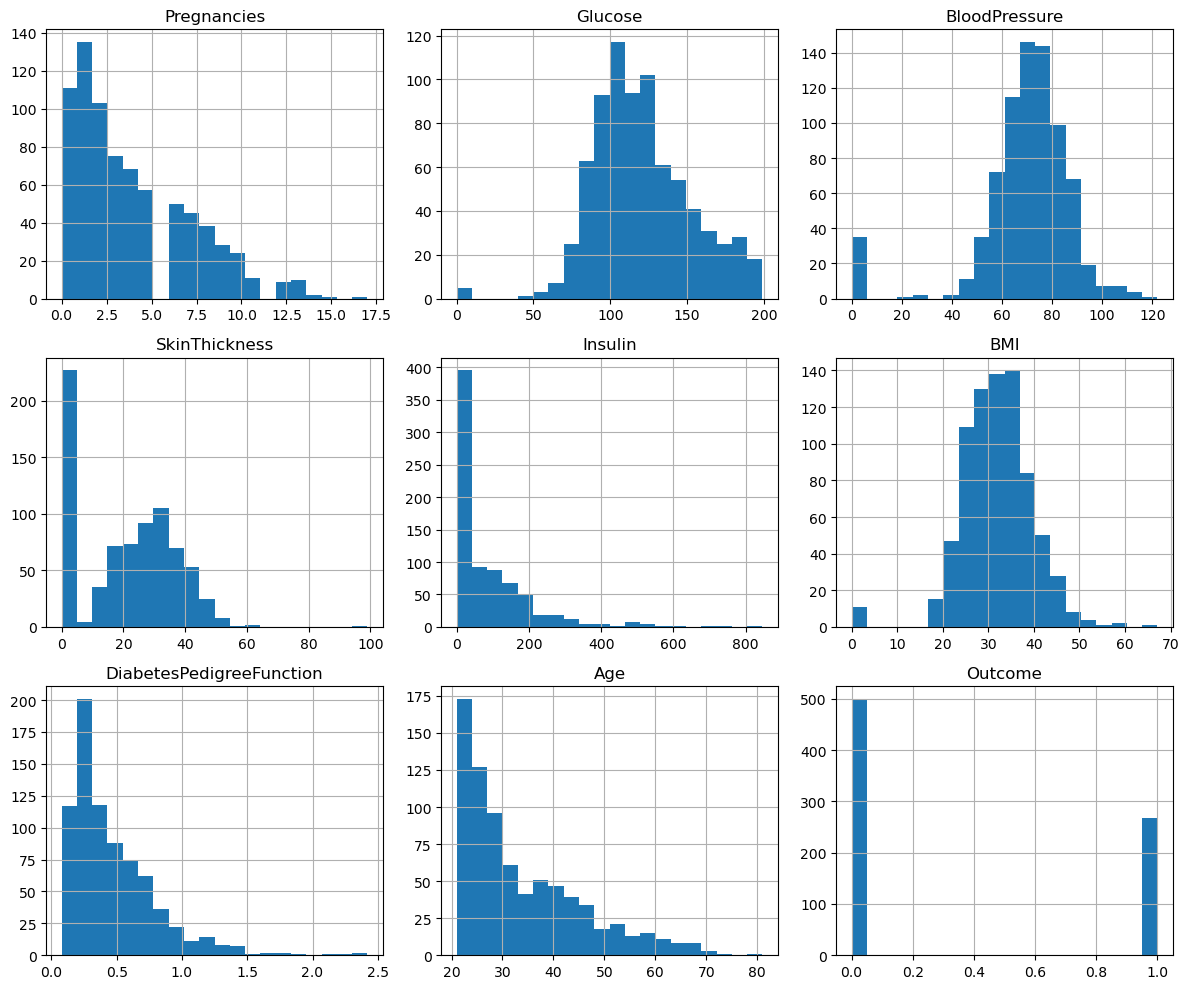

In [260]:
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

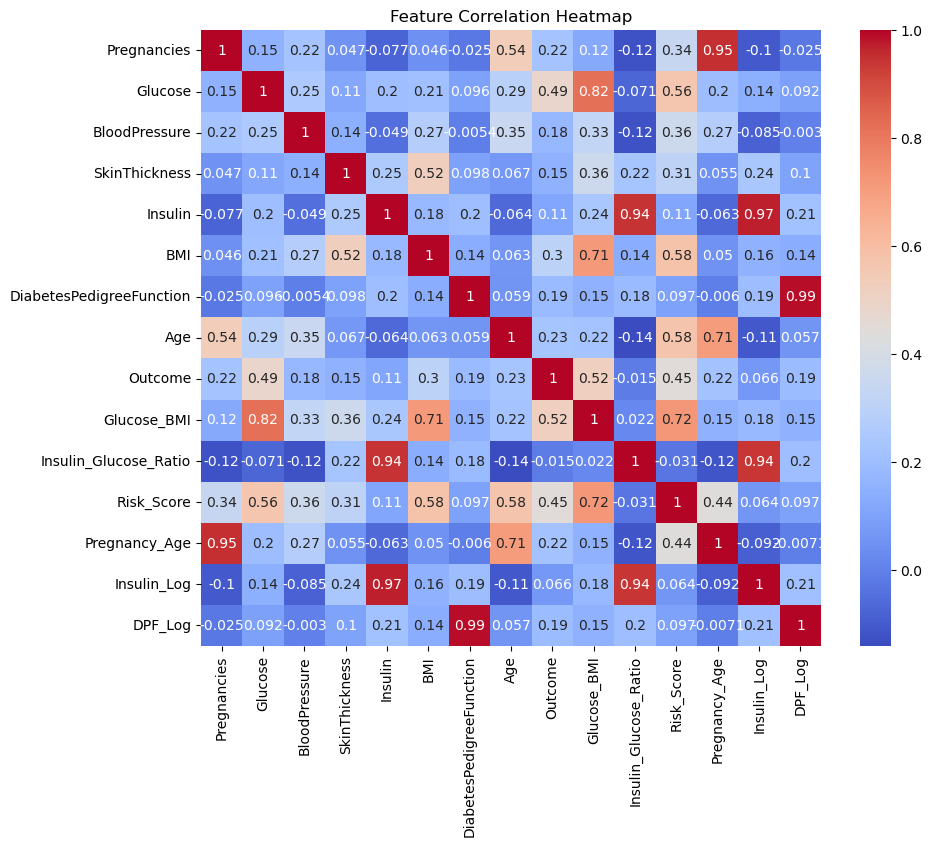

In [284]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Feature Correlation Heatmap')
plt.show()

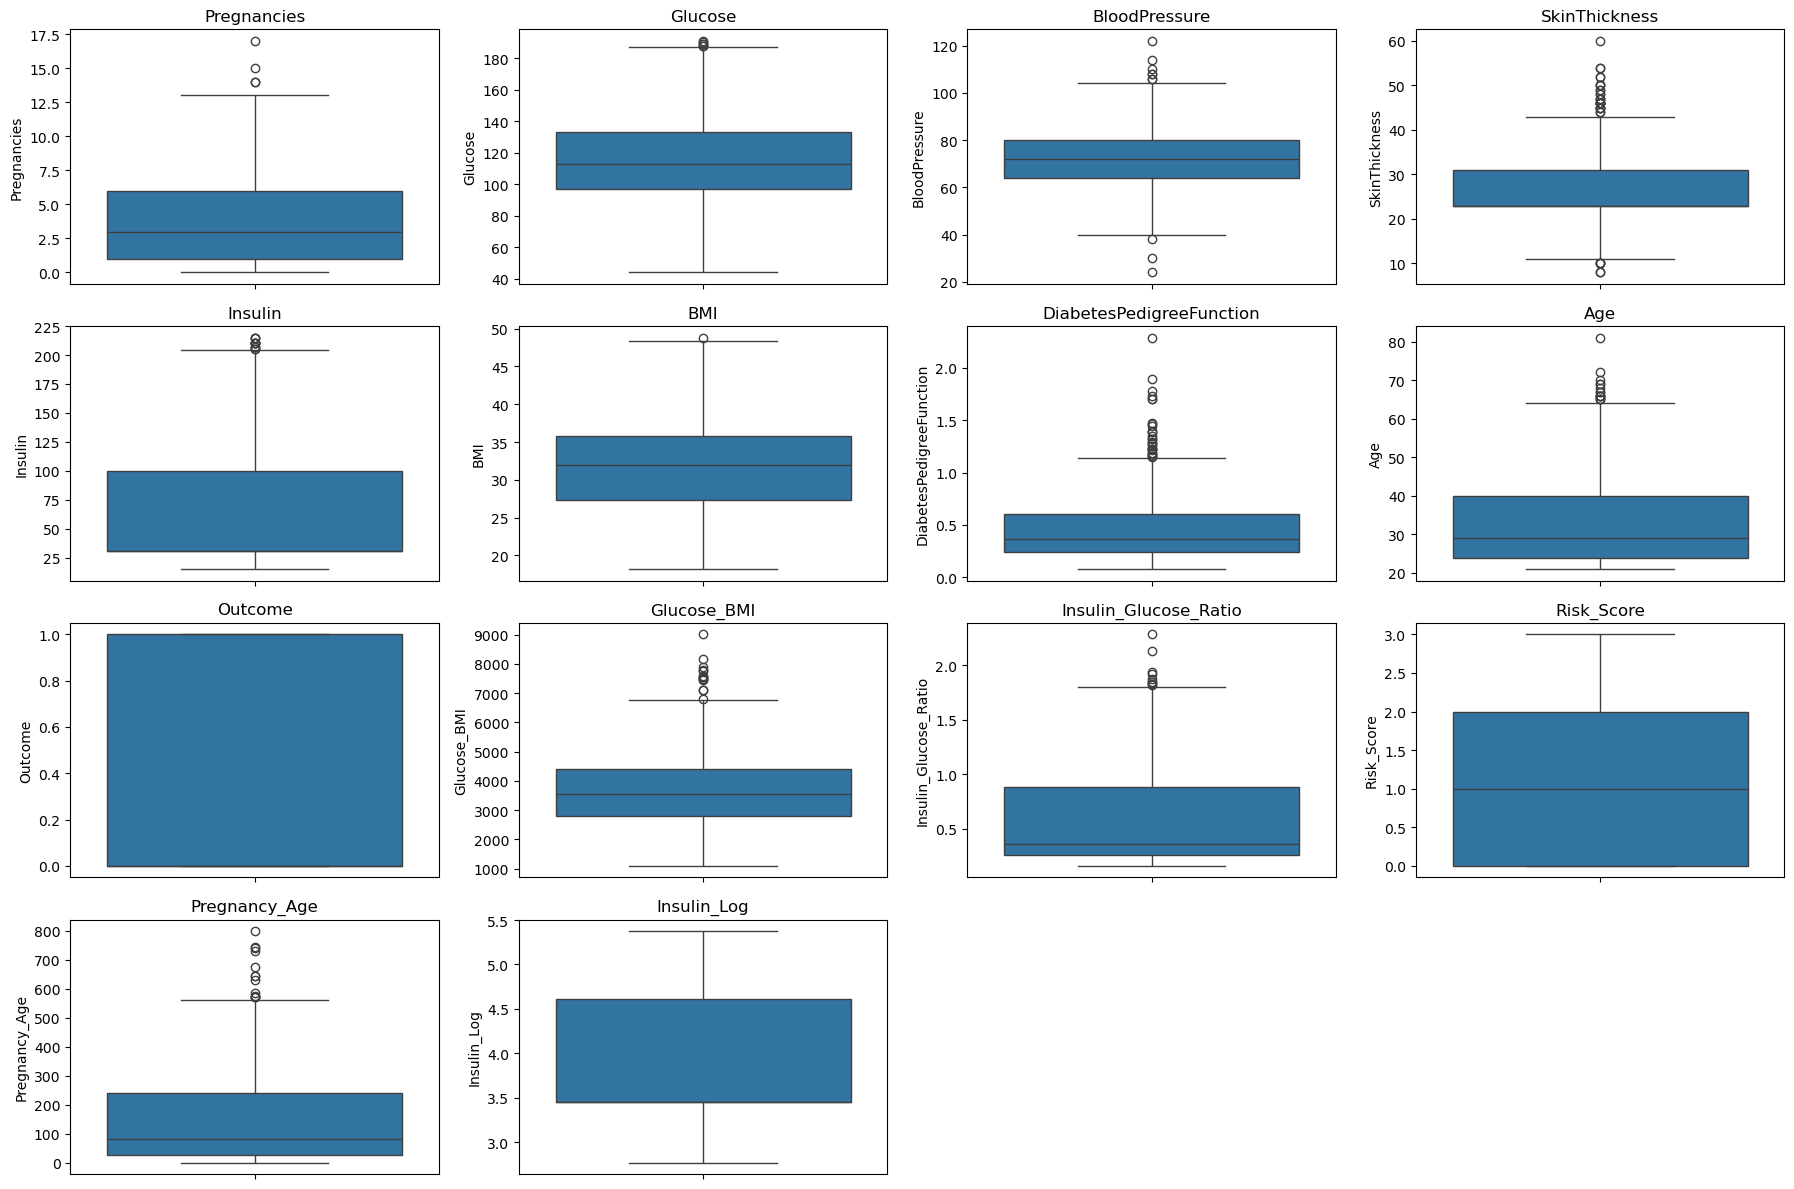

In [307]:
plt.figure(figsize=(18,12))

for i, col in enumerate(df.columns[:-1], 1):
    
    plt.subplot(4,4,i)
    
    sns.boxplot(y=df[col])
    
    plt.title(col)

plt.tight_layout()

plt.show()

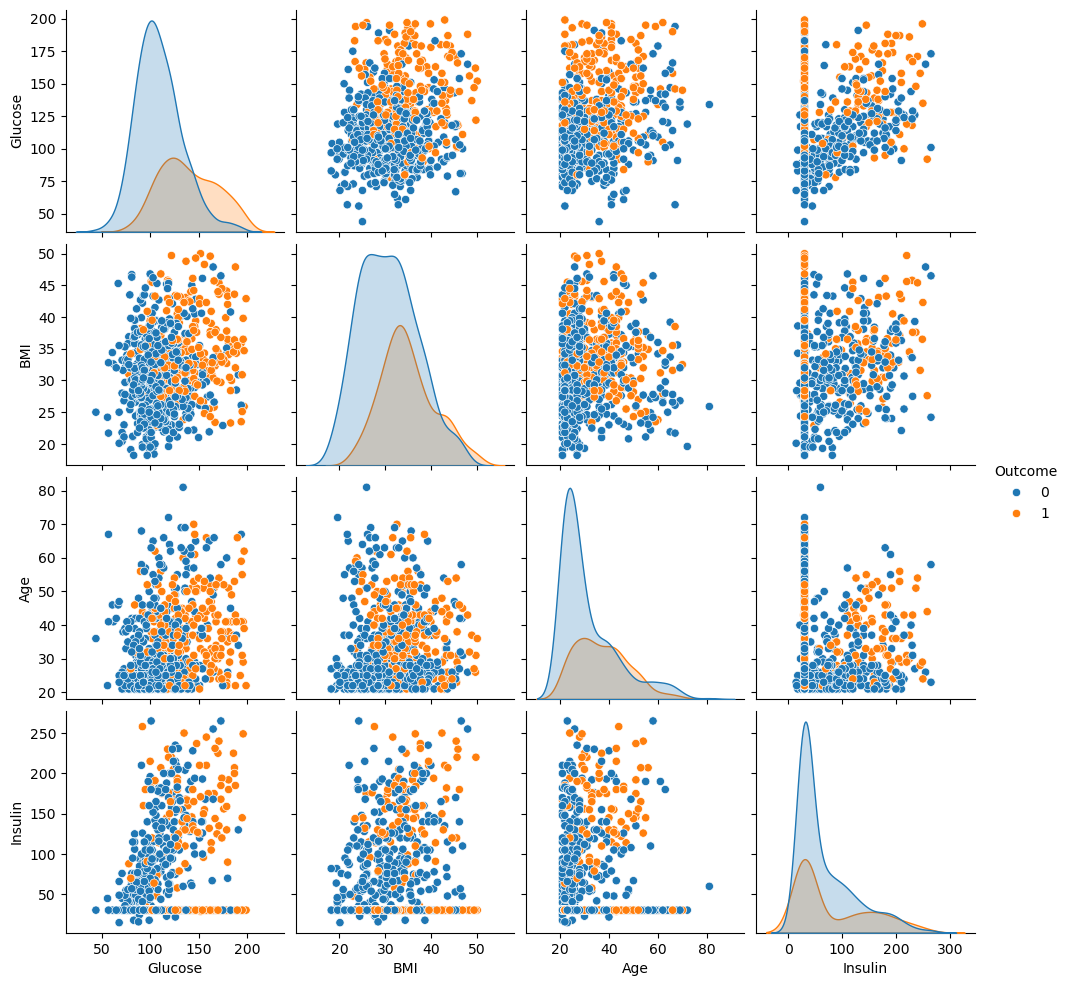

In [287]:
sns.pairplot(
    df[['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']],
    hue='Outcome'
)

plt.show()

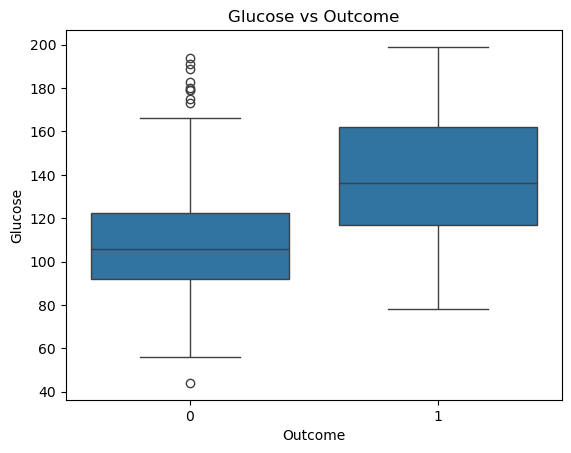

In [288]:
sns.boxplot(x='Outcome', y='Glucose', data=df)

plt.title('Glucose vs Outcome')
plt.show()

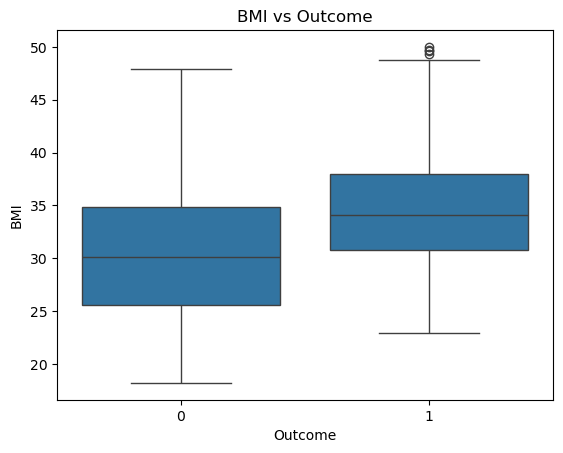

In [289]:
sns.boxplot(x='Outcome', y='BMI', data=df)

plt.title('BMI vs Outcome')
plt.show()

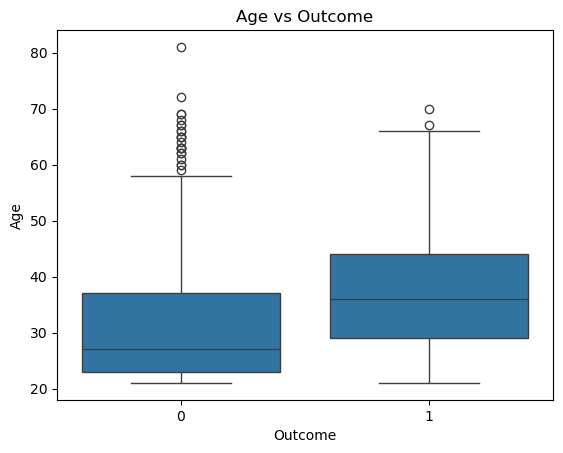

In [290]:
sns.boxplot(x='Outcome', y='Age', data=df)

plt.title('Age vs Outcome')
plt.show()

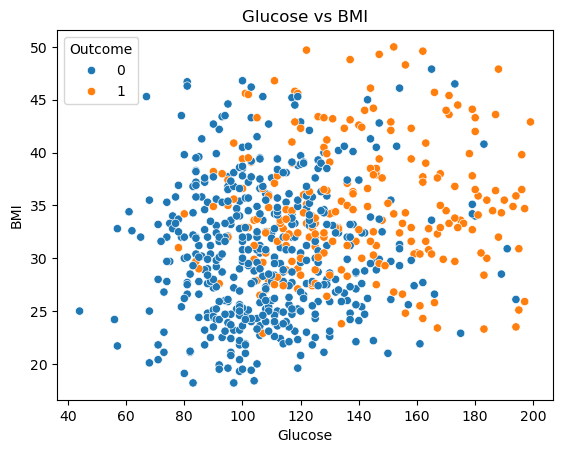

In [291]:
sns.scatterplot(
    x='Glucose',
    y='BMI',
    hue='Outcome',
    data=df
)

plt.title('Glucose vs BMI')
plt.show()

In [292]:
cols_with_zero = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for col in cols_with_zero:
    df[col] = df[col].replace(0, df[col].median())

In [293]:
important_cols = [
    'Glucose',
    'BMI',
    'Insulin'
]

for col in important_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

In [294]:
# Strong interaction feature
df['Glucose_BMI'] = (
    df['Glucose'] * df['BMI']
)

# Insulin resistance feature
df['Insulin_Glucose_Ratio'] = (
    df['Insulin'] / (df['Glucose'] + 1)
)

# Risk score
df['Risk_Score'] = (
    (df['Glucose'] > 140).astype(int)
    +
    (df['BMI'] > 30).astype(int)
    +
    (df['Age'] > 40).astype(int)
)

# Pregnancy-age interaction
df['Pregnancy_Age'] = (
    df['Pregnancies'] * df['Age']
)

# Log transforms
df['Insulin_Log'] = np.log1p(df['Insulin'])

df['DPF_Log'] = np.log1p(
    df['DiabetesPedigreeFunction']
)

In [295]:
X = df.drop("Outcome", axis=1)

Y = df['Outcome']

In [296]:
X = df[
    [
        'Glucose',
        'BMI',
        'Age',
        'Pregnancies',
        'Glucose_BMI',
        'Risk_Score',
        'Insulin_Glucose_Ratio',
        'Pregnancy_Age',
        'Insulin_Log',
        'DPF_Log'
    ]
]

y = df['Outcome']

In [297]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)


In [298]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [304]:
knn = KNeighborsClassifier(
    n_neighbors=15,
    metric='manhattan',
    weights='distance'
)

knn.fit(X_train_scaled, Y_train)

,n_neighbors,15
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [305]:
Y_pred = knn.predict(X_test_scaled)

In [306]:
acc = accuracy_score(Y_test, Y_pred)
print("Accuracy:", acc)

Accuracy: 0.8235294117647058


In [308]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.84      0.93      0.88        95
           1       0.77      0.59      0.67        41

    accuracy                           0.82       136
   macro avg       0.81      0.76      0.77       136
weighted avg       0.82      0.82      0.82       136



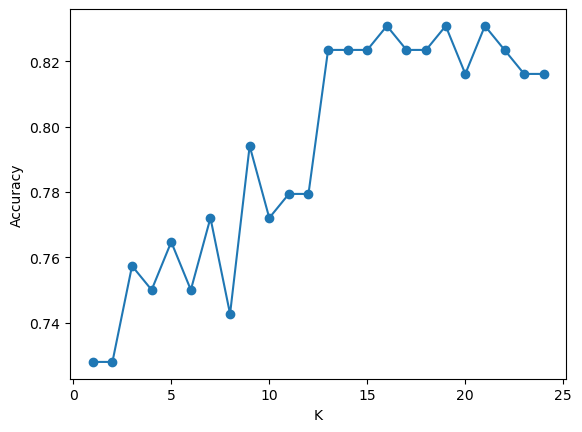

In [303]:
scores = []

for k in range(1, 25):

    model = KNeighborsClassifier(
        n_neighbors=k,
        metric='manhattan',
        weights='distance'
    )

    model.fit(X_train_scaled, Y_train)

    pred = model.predict(X_test_scaled)

    scores.append(
        accuracy_score(Y_test, pred)
    )

plt.plot(range(1,25), scores, marker='o')

plt.xlabel("K")
plt.ylabel("Accuracy")

plt.show()